# Aggregated numerical validation boxplots
Relative differences between empirical and theoretical distributions, split by study (baseline vs longitudinal).

In [15]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re
from typing import Literal, Optional, List

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# ----------------------------
# Project discovery
# ----------------------------
def find_project_root() -> Path:
    """
    Locate a project root that contains results/numerical_validation/csv.
    Searches a few likely locations relative to the current working directory.
    """
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd.parent,
        cwd.parent.parent,
        cwd / "freesurfer-fuzzy",
        cwd.parent / "freesurfer-fuzzy",
    ]
    for c in candidates:
        if (c / "results" / "numerical_validation" / "csv").is_dir():
            return c
    raise FileNotFoundError(
        "Could not locate results/numerical_validation/csv in expected locations."
    )


ROOT = find_project_root()
CSV_DIR = ROOT / "results" / "numerical_validation" / "csv"


# ----------------------------
# Domain constants
# ----------------------------
TEST_ORDER = ["student", "ancova", "partial_correlation", "cohen_d"]
TEST_LABELS = {
    "student": "Two-sample t-test",
    "ancova": "ANCOVA",
    "partial_correlation": "Partial correlation",
    "cohen_d": "Cohen's d",
}
# Symbol used in column prefixes like t_mean, F_mean, r_mean, cohen_d_mean
TEST_SYMBOL = {
    "student": "t",
    "ancova": "F",
    "partial_correlation": "r",
    "cohen_d": "cohen_d",
}

METRIC_ORDER = ["thickness", "area", "volume", "subcortical_volume"]
METRIC_LABELS = {
    "thickness": "cortical thickness",
    "area": "cortical area",
    "volume": "cortical volume",
    "subcortical_volume": "subcortical volume",
}

STUDY_ORDER = ["baseline", "longitudinal"]
STUDY_COLORS = {"baseline": "#0072B2", "longitudinal": "#D55E00"}
STUDY_LABELS = {"baseline": "Cross-sectional", "longitudinal": "Longitudinal"}

ValueType = Literal["stat", "pvalue"]
ErrorType = Literal["abs", "rel"]

subcortical_regions = [
    "Left-Thalamus",
    "Left-Caudate",
    "Left-Putamen",
    "Left-Pallidum",
    "Left-Hippocampus",
    "Left-Amygdala",
    "Left-Accumbens-area",
    "Right-Thalamus",
    "Right-Caudate",
    "Right-Putamen",
    "Right-Pallidum",
    "Right-Hippocampus",
    "Right-Amygdala",
    "Right-Accumbens-area",
]

# Cortical regions in DKT atlas
cortical_regions = [
    "bankssts",
    "caudalanteriorcingulate",
    "caudalmiddlefrontal",
    "cuneus",
    "entorhinal",
    "fusiform",
    "inferiorparietal",
    "inferiortemporal",
    "isthmuscingulate",
    "lateraloccipital",
    "lateralorbitofrontal",
    "lingual",
    "medialorbitofrontal",
    "middletemporal",
    "parahippocampal",
    "paracentral",
    "parsopercularis",
    "parsorbitalis",
    "parstriangularis",
    "pericalcarine",
    "postcentral",
    "posteriorcingulate",
    "precentral",
    "precuneus",
    "rostralanteriorcingulate",
    "rostralmiddlefrontal",
    "superiorfrontal",
    "superiorparietal",
    "superiortemporal",
    "supramarginal",
    "frontalpole",
    "temporalpole",
    "transversetemporal",
    "insula",
]


@dataclass(frozen=True)
class ParsedFile:
    test_key: str
    metric_key: str
    path: Path


_AGG_PATTERN = re.compile(r"(?P<test>.+)_aggregated_(?P<metric>.+)\.csv$")


def _parse_aggregated_filename(path: Path) -> Optional[ParsedFile]:
    m = _AGG_PATTERN.match(path.name)
    if not m:
        return None
    test_key = m.group("test")
    metric_key = m.group("metric")
    if test_key not in TEST_ORDER or metric_key not in METRIC_ORDER:
        return None
    return ParsedFile(test_key=test_key, metric_key=metric_key, path=path)


def _choose_value_column(
    df: pd.DataFrame,
    *,
    value_type: ValueType,
    test_symbol: str,
    signed: bool = False,
    error_type: ErrorType = "rel",
) -> str:
    """
    Determine which column to plot.
    - pvalue => p-val_std_diff_rel(_signed)
    - stat   => {test_symbol}_std_diff_rel(_signed) (preferred)
              else any single non-pvalue *_std_diff_rel(_signed) (fallback with validation)
    """
    error = "_rel" if error_type == "rel" else ""
    if value_type == "pvalue":
        col = f"p-val_std_diff{error}_signed" if signed else f"p-val_std_diff{error}"
        if col not in df.columns and signed:
            col = f"p-val_std_diff{error}"
        if col not in df.columns:
            raise KeyError(f"Missing required column '{col}'.")
        return col

    preferred = (
        f"{test_symbol}_std_diff{error}_signed"
        if signed
        else f"{test_symbol}_std_diff{error}"
    )
    if preferred in df.columns:
        return preferred

    # Fallback: accept exactly one *_std_diff_rel excluding pvalue
    suffix = f"_std_diff{error}_signed" if signed else f"_std_diff{error}"
    candidates = [
        c for c in df.columns if c.endswith(suffix) and not c.startswith("p-val")
    ]
    if len(candidates) == 1:
        return candidates[0]

    if signed:
        candidates = [
            c
            for c in df.columns
            if c.endswith(f"_std_diff{error}") and c != f"p-val_std_diff{error}"
        ]
        if len(candidates) == 1:
            return candidates[0]

    raise KeyError(
        "Could not determine statistic std-diff column. "
        f"Expected '{preferred}' or a single '*_std_diff{error}' column. "
        f"Found: {candidates}"
    )


def load_aggregated_data(
    *,
    value_type: ValueType = "stat",
    signed: bool = False,
    error_type: ErrorType = "rel",
) -> pd.DataFrame:
    """
    Load all *_aggregated_*.csv files and return a tidy dataframe with:
      - test_key, test_symbol, metric_key, study, value
    """
    frames: List[pd.DataFrame] = []

    for csv_path in CSV_DIR.glob("*_aggregated_*.csv"):
        parsed = _parse_aggregated_filename(csv_path)
        if parsed is None:
            continue

        df = pd.read_csv(csv_path)

        if "study" not in df.columns:
            # Skip files that don't have study info (by design in your plot)
            continue

        # Ensure we always have metric even if the CSV doesn't
        if "metric" not in df.columns:
            df["metric"] = parsed.metric_key

        if df["metric"].unique()[0] == "subcortical_volume":
            # Filter to subcortical regions only, since some files include both
            df = df[df["region"].isin(subcortical_regions)]
        else:
            # Filter to cortical regions only, since some files include both
            df = df[df["region"].isin(cortical_regions)]

        test_symbol = TEST_SYMBOL[parsed.test_key]
        try:
            value_col = _choose_value_column(
                df,
                value_type=value_type,
                test_symbol=test_symbol,
                signed=signed,
                error_type=error_type,
            )
        except KeyError:
            continue  # or raise, if you prefer strict behavior

        # Filter to the study values we care about, and build a tidy frame
        sub = df[df["study"].isin(STUDY_ORDER)].copy()
        if sub.empty:
            continue

        sub["test_key"] = parsed.test_key
        sub["test_symbol"] = test_symbol
        sub["metric_key"] = parsed.metric_key
        sub["value"] = pd.to_numeric(sub[value_col], errors="coerce")

        # keep only what we need (plus metric/study)
        frames.append(
            sub[["test_key", "test_symbol", "metric", "metric_key", "study", "value"]]
        )

    if not frames:
        return pd.DataFrame(
            columns=[
                "test_key",
                "test_symbol",
                "metric",
                "metric_key",
                "study",
                "value",
            ]
        )

    out = pd.concat(frames, ignore_index=True)

    # Make ordering deterministic for Plotly category axes
    out["metric"] = pd.Categorical(out["metric"], categories=METRIC_ORDER, ordered=True)
    out["study"] = pd.Categorical(out["study"], categories=STUDY_ORDER, ordered=True)
    out["test_key"] = pd.Categorical(
        out["test_key"], categories=TEST_ORDER, ordered=True
    )

    return out


def plot_relative_difference_violins(
    *,
    value_type: ValueType = "stat",
    signed: bool = False,
    error_type: ErrorType = "rel",
) -> go.Figure:
    data = load_aggregated_data(
        value_type=value_type, signed=signed, error_type=error_type
    )

    y_title = "p-value" if value_type == "pvalue" else "statistic"

    subplot_titles = [TEST_LABELS[t] for t in TEST_ORDER]
    if value_type == "pvalue":
        # remove cohen's d subplot since it doesn't have p-values
        subplot_titles = [TEST_LABELS[t] for t in TEST_ORDER if t != "cohen_d"]

    fig = make_subplots(
        rows=2,
        cols=2,
        subplot_titles=subplot_titles,
        vertical_spacing=0.1,
        horizontal_spacing=0.02,
        x_title="Metric",
        y_title=y_title,
        shared_xaxes=True,
        shared_yaxes=True,
    )

    for i, test_key in enumerate(TEST_ORDER):
        row, col = (i // 2) + 1, (i % 2) + 1

        test_data = data[data["test_key"] == test_key]
        if test_data.empty:
            continue

        for study in STUDY_ORDER:
            sub = test_data[test_data["study"] == study]
            sub = sub[sub["value"].notna()]
            if sub.empty:
                continue

            # 1) In add_trace(...) set width + alignment/scale groups
            fig.add_trace(
                go.Violin(
                    x=sub["metric"],
                    y=sub["value"],
                    name=STUDY_LABELS[study],
                    legendgroup=STUDY_LABELS[study],
                    marker_color=STUDY_COLORS[study],
                    # Make violins fat enough
                    # Make both studies align & scale together per subplot/test
                    alignmentgroup=f"{test_key}",
                    scalegroup=f"{test_key}",
                    offsetgroup=STUDY_LABELS[study],
                    scalemode="width",
                    meanline=dict(visible=True),
                    points="all",
                    pointpos=-1.2,
                    jitter=0.12,
                    marker=dict(size=4, opacity=0.5),
                    showlegend=(i == 0),
                    spanmode="hard",
                ),
                row=row,
                col=col,
            )

            mean = sub["value"].mean()
            std = sub["value"].std()
            print(f"{test_key} - {study}: mean={mean:.4f}, std={std:.4f}")

    fig.update_layout(
        title="Relative differences between sampled and analytical distributions",
        violinmode="group",  # <-- key change
        violingap=0.15,
        violingroupgap=0.2,
        template="simple_white",
        font=dict(family="Helvetica", size=16, color="black"),
        width=1200,
        height=780,
        margin=dict(l=70, r=30, t=80, b=70),
        legend=dict(title="", orientation="v", y=1.05, x=1.08, xanchor="right"),
        title_x=0.5,
    )

    # Consistent x-axis ordering + nicer labels
    fig.update_xaxes(
        categoryorder="array",
        categoryarray=METRIC_ORDER,
        tickmode="array",
        tickvals=METRIC_ORDER,
        ticktext=[METRIC_LABELS[m] for m in METRIC_ORDER],
        tickfont=dict(family="Helvetica", size=12, color="black"),
        showline=True,
        linewidth=1,
        linecolor="black",
        ticks="outside",
        ticklen=4,
    )

    if error_type == "rel":
        # For relative differences, we expect values roughly between -1 and 1, so set consistent y-lims
        if signed:
            y_range = [-1.02, 1.02]
        else:
            y_range = [-0.02, 1.02]
    else:
        # For absolute differences, we don't have a clear expected range, so let it autoscale but still show the axis line
        y_range = None

    fig.update_yaxes(
        range=y_range,
        showline=True,
        linewidth=1,
        linecolor="black",
        ticks="outside",
        ticklen=4,
        zeroline=False,
    )

    fig.add_hline(
        y=0,
        row="all",
        col="all",
        line_color="black",
        line_dash="solid",
        line_width=1,
        layer="below",
        opacity=0.75,
    )

    fig.update_annotations(
        font=dict(family="Helvetica", size=18, color="black"),
        # yshift=10,
    )

    return fig


fig = plot_relative_difference_violins(value_type="stat", signed=True, error_type="rel")
fig.show()


student - baseline: mean=-0.0139, std=0.1603
student - longitudinal: mean=-0.0101, std=0.1447
ancova - baseline: mean=0.0145, std=0.2004
ancova - longitudinal: mean=-0.1843, std=0.2072
partial_correlation - baseline: mean=0.0788, std=0.2602
partial_correlation - longitudinal: mean=-0.0015, std=0.1838
cohen_d - baseline: mean=-0.0138, std=0.1596
cohen_d - longitudinal: mean=-0.0027, std=0.1457


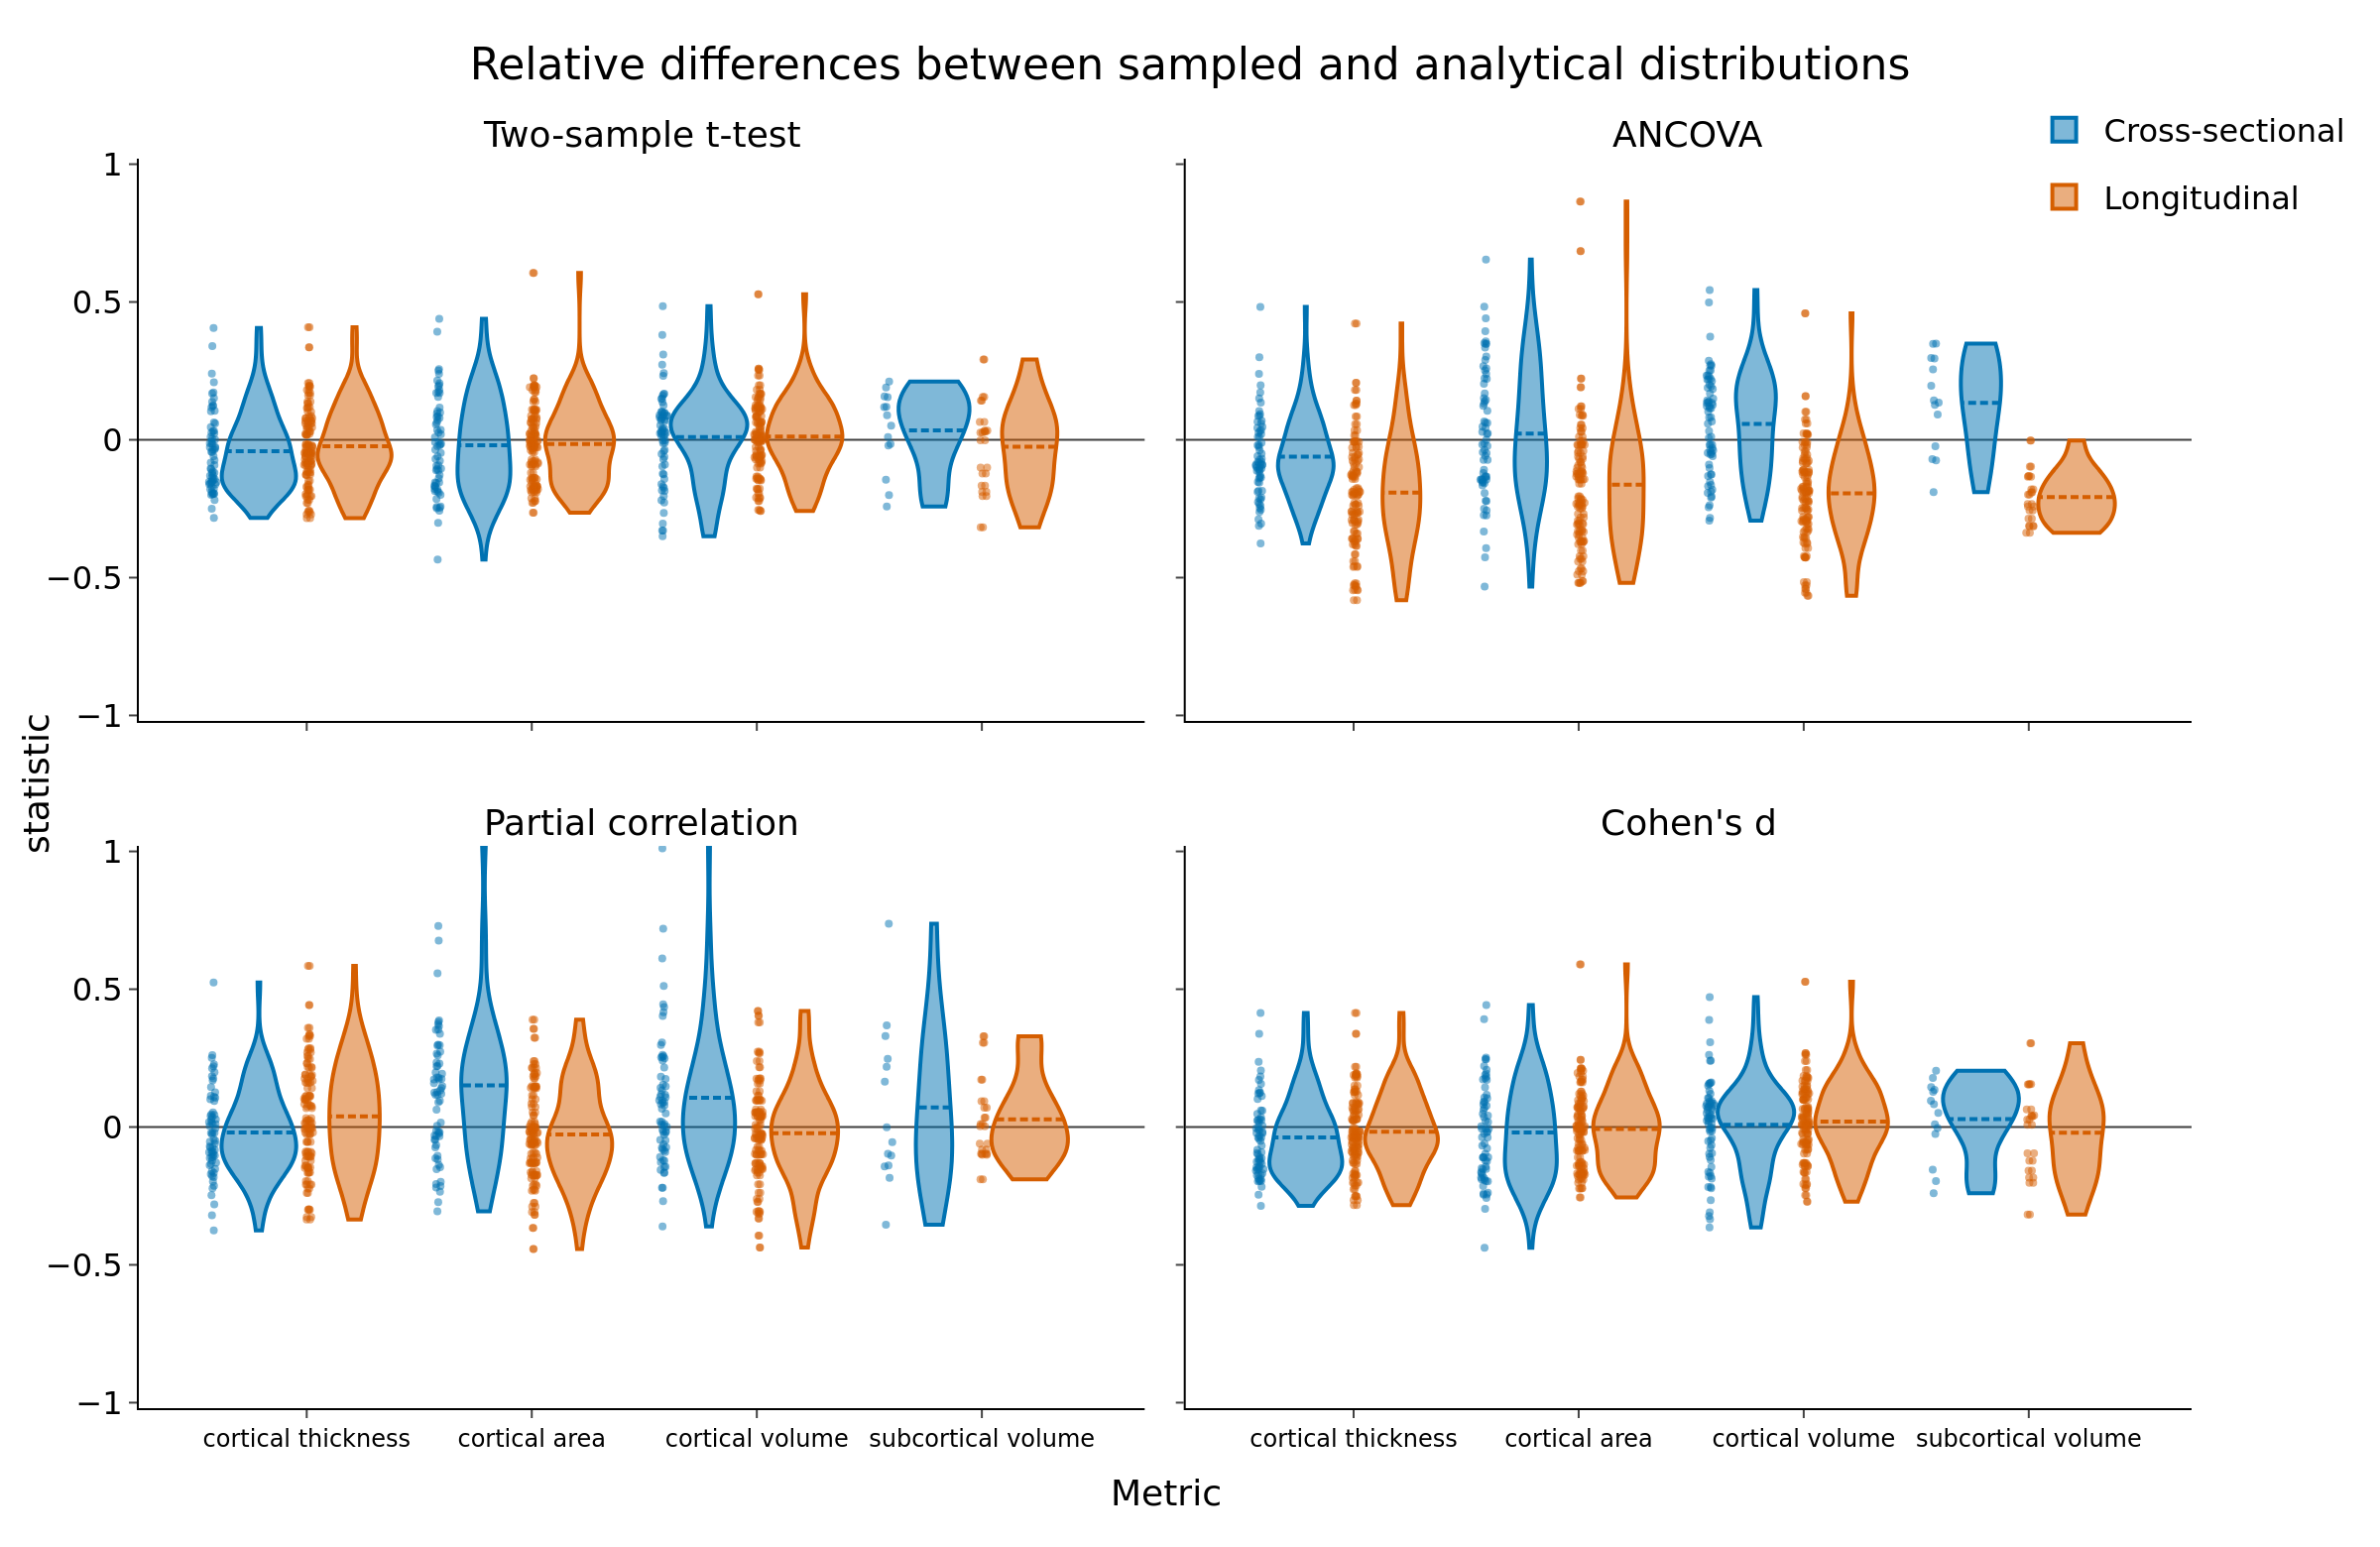

In [16]:
from IPython.display import Image, display

from matplotlib import scale

fig.write_image(
    ROOT
    / "results"
    / "numerical_validation"
    / "aggregated_relative_difference_violins_stat.pdf",
    scale=2,
)
fig.write_image(
    ROOT
    / "results"
    / "numerical_validation"
    / "aggregated_relative_difference_violins_stat.png",
    scale=2,
)
display(
    Image(
        filename=ROOT
        / "results"
        / "numerical_validation"
        / "aggregated_relative_difference_violins_stat.png"
    )
)


In [17]:
fig = plot_relative_difference_violins(
    value_type="pvalue", signed=True, error_type="rel"
)
fig.show()


student - baseline: mean=0.0539, std=0.3005
student - longitudinal: mean=-0.2508, std=0.3738
ancova - baseline: mean=0.1061, std=0.3228
ancova - longitudinal: mean=-0.1172, std=0.4257
partial_correlation - baseline: mean=0.0429, std=0.3216
partial_correlation - longitudinal: mean=-0.2326, std=0.3099


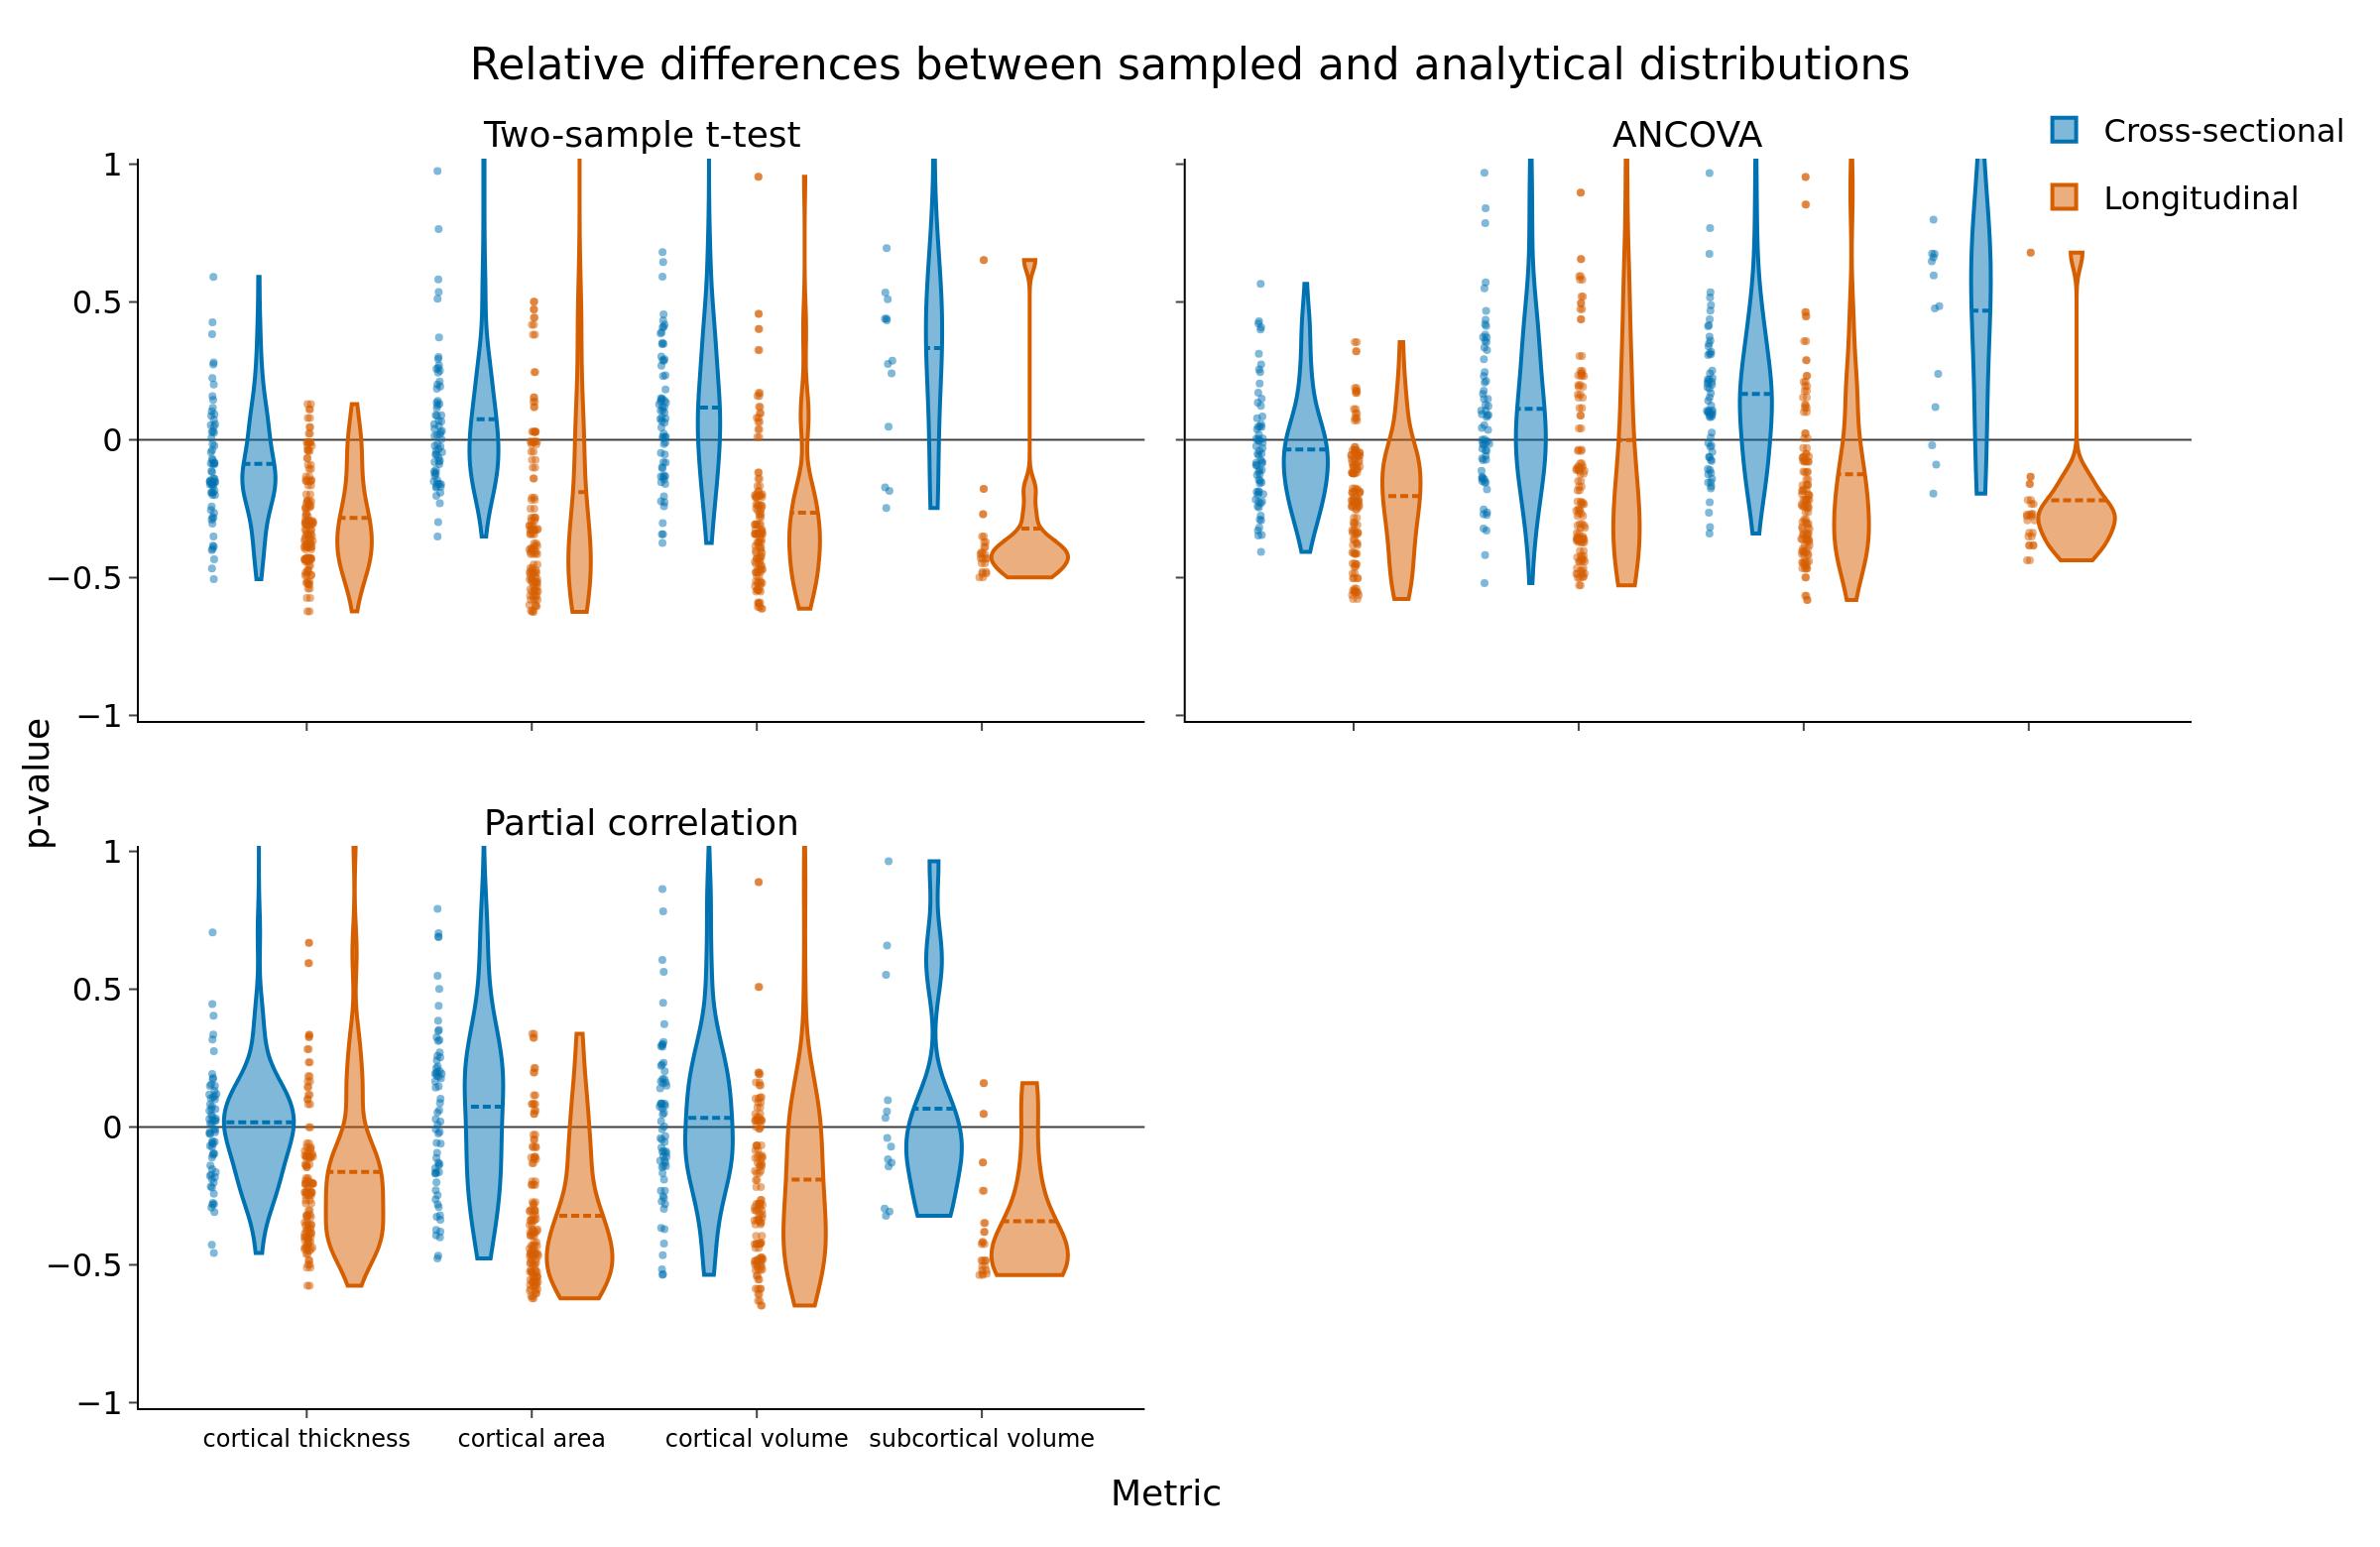

In [18]:
from IPython.display import Image, display

fig.write_image(
    ROOT
    / "results"
    / "numerical_validation"
    / "aggregated_relative_difference_violins_pvalue.pdf",
    scale=2,
)
fig.write_image(
    ROOT
    / "results"
    / "numerical_validation"
    / "aggregated_relative_difference_violins_pvalue.png",
    scale=2,
)
display(
    Image(
        ROOT
        / "results"
        / "numerical_validation"
        / "aggregated_relative_difference_violins_pvalue.png"
    )
)